# Detecção de Fraude em Transações de Cartão de Crédito com Aprendizado de Máquina

**Desafio de Projeto — Bootcamp Bradesco - GenAI & Dados em parceria com a DIO** 

## Resumo

Neste projeto, desenvolvo um pipeline completo de classificação para identificar transações fraudulentas de cartão de crédito, desde a exploração dos dados até a explicação das decisões do modelo. A base utilizada é fortemente desbalanceada: apenas cerca de 0,17% das transações são fraude. Nesse contexto, a acurácia é uma métrica enganosa, pois um classificador que sempre responde "não é fraude" atinge cerca de 99,8% de acerto sem detectar nenhuma fraude. Por isso, avalio os modelos principalmente pelo **recall**, pela **precisão** e pelo **F1** da classe fraude, complementados pelas curvas ROC e de precisão e recall.

Comparo três algoritmos (regressão logística, Random Forest e XGBoost), trato o desbalanceamento por meio do peso das classes, ajusto o limiar de decisão em um conjunto de validação separado e, por fim, interpreto o modelo com importância de variáveis e SHAP.

## Base de dados

Utilizo o conjunto `creditcard.csv`, carregado diretamente por link público (não é armazenado neste repositório). As colunas são `Time`, `Amount`, `Class` (0 = normal, 1 = fraude) e `V1` a `V28`, que são componentes obtidos por PCA e, por isso, não têm significado direto interpretável.

Fonte: https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv

> **Nota de reprodutibilidade:** o notebook requer conexão com a internet (para baixar a base) e as bibliotecas `xgboost`, `shap` e `matplotlib`, instaladas na célula seguinte. Todas as sementes aleatórias estão fixadas.

In [2]:
# Instalação das dependências 
%pip install -q xgboost shap matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    f1_score,
    average_precision_score,
)

from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42  # semente usada em todas as etapas aleatórias, para reprodutibilidade

pd.set_option("display.max_columns", 40)

c:\Users\Samyra\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Exploração dos dados

Inicio carregando a base e verificando sua estrutura. Em seguida, meço a proporção de fraudes, pois esse valor justifica todas as decisões metodológicas tomadas nas etapas seguintes.

In [5]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

print("Formato do dataset:", df.shape)
df.head()

Formato do dataset: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

       contagem  percentual (%)
Class                          
0        284315          99.827
1           492           0.173


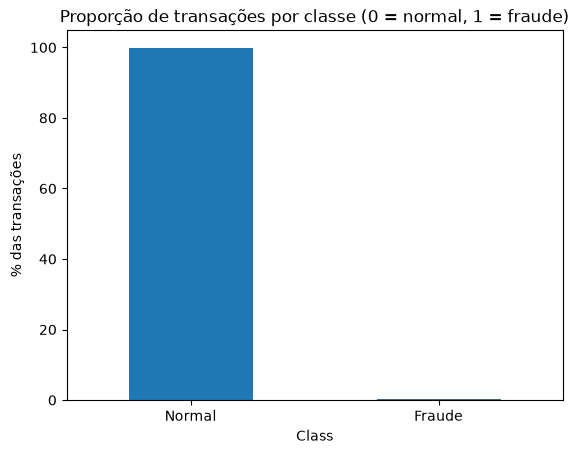

In [7]:
contagem = df["Class"].value_counts()
proporcao = df["Class"].value_counts(normalize=True) * 100

resumo = pd.DataFrame({"contagem": contagem, "percentual (%)": proporcao.round(3)})
print(resumo)

resumo["percentual (%)"].plot(
    kind="bar", title="Proporção de transações por classe (0 = normal, 1 = fraude)"
)
plt.ylabel("% das transações")
plt.xticks([0, 1], ["Normal", "Fraude"], rotation=0)
plt.show()

**Análise.** A base contém 284.807 transações, das quais apenas 492 (0,173%) são fraudes. Um classificador trivial que sempre prevê "normal" teria acurácia de aproximadamente 99,83%, sem detectar nenhuma fraude. Isso mostra que a acurácia não é adequada para este problema e que as métricas relevantes são recall, precisão e F1 da classe fraude. Além disso, o desbalanceamento faz com que os algoritmos, se treinados sem nenhum cuidado, tendam a ignorar a classe minoritária, já que ela contribui pouco para a função de perda.

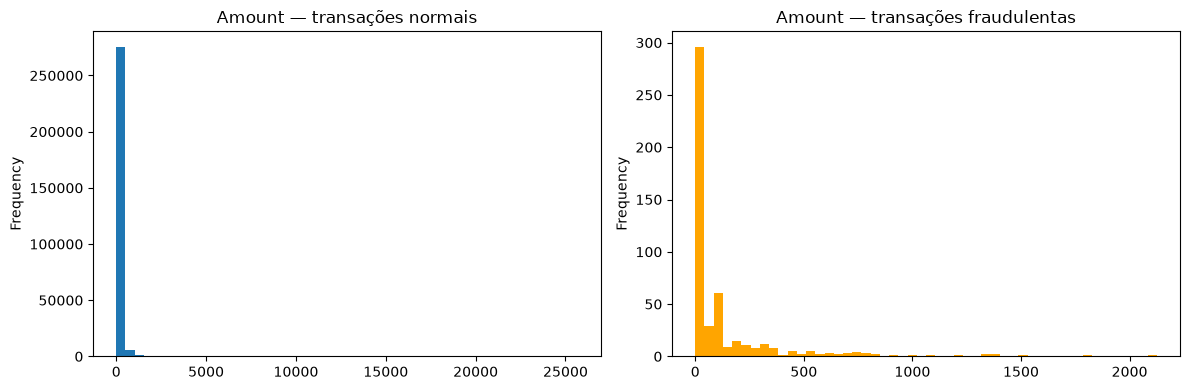

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df["Class"] == 0]["Amount"].plot(kind="hist", bins=50, ax=axes[0], title="Amount — transações normais")
df[df["Class"] == 1]["Amount"].plot(kind="hist", bins=50, ax=axes[1], title="Amount — transações fraudulentas", color="orange")

plt.tight_layout()
plt.show()

df.groupby("Class")["Amount"].describe()

**Análise.** A distribuição de `Amount` é fortemente assimétrica nas duas classes, com muitos valores baixos e poucos valores muito altos. Observo também que a mediana das fraudes (9,25 na unidade monetária da base) é menor que a das transações normais (22,00), embora a média das fraudes seja maior (122,21 contra 88,29). Isso indica que as fraudes se concentram em valores baixos, mas com cauda longa de valores altos, o que motiva a transformação logarítmica na etapa seguinte.

## 2. Preparação dos dados

As decisões desta etapa foram as seguintes:

- **Variável nova `LogAmount`**, calculada como `log(1 + Amount)`, para reduzir a assimetria do valor da transação. Uso `log1p` porque existem transações com `Amount = 0`, para as quais o logaritmo simples seria indefinido.
- **Remoção de `Time` e de `Amount` original.** `Time` é apenas o número de segundos desde a primeira transação da base; em seu formato bruto ele não generaliza para dados futuros. `Amount` é substituído pela versão logarítmica.
- **Padronização com `StandardScaler`**, necessária principalmente para a regressão logística. Os modelos baseados em árvores não dependem de escala, por isso recebem os dados sem padronização.
- **Separação estratificada** (`stratify=y`), para manter a mesma proporção de fraudes em todos os subconjuntos. Sem isso, o conjunto de teste poderia ficar com pouquíssimas fraudes, tornando a avaliação instável.
- **Três subconjuntos:** o conjunto de teste (20%) é reservado apenas para a avaliação final. Do restante, separo ainda uma parte de validação (25% do treino), usada **somente para escolher o limiar de decisão**. Escolher o limiar no próprio conjunto de teste tornaria a avaliação otimista, pois o teste deixaria de ser um dado inédito para o modelo.

In [9]:
df_prep = df.copy()
df_prep["LogAmount"] = np.log1p(df_prep["Amount"])

features = [c for c in df_prep.columns if c not in ["Class", "Time", "Amount"]]
X = df_prep[features]
y = df_prep["Class"]

# 1) separação treino / teste (teste fica intocado até a avaliação final)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Treino:", X_train.shape, "| proporção de fraude:", round(y_train.mean(), 5))
print("Teste: ", X_test.shape, "| proporção de fraude:", round(y_test.mean(), 5))

Treino: (227845, 29) | proporção de fraude: 0.00173
Teste:  (56962, 29) | proporção de fraude: 0.00172


In [10]:
# 2) do treino, separo uma parte de validação, usada apenas para escolher o limiar de decisão
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_STATE
)

print("Fit:      ", X_fit.shape, "| fraudes:", int(y_fit.sum()))
print("Validação:", X_val.shape, "| fraudes:", int(y_val.sum()))
print("Teste:    ", X_test.shape, "| fraudes:", int(y_test.sum()))

Fit:       (170883, 29) | fraudes: 295
Validação: (56962, 29) | fraudes: 99
Teste:     (56962, 29) | fraudes: 98


In [11]:
# Padronização: o scaler é ajustado apenas nos dados de treino, para evitar vazamento de informação (data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scaler separado para o modelo auxiliar da etapa de escolha do limiar (ajustado só no subconjunto "fit")
scaler_fit = StandardScaler()
X_fit_scaled = scaler_fit.fit_transform(X_fit)
X_val_scaled = scaler_fit.transform(X_val)

## 3. Modelagem

Treino três algoritmos, do mais simples ao mais complexo:

1. **Regressão logística**, como baseline linear e interpretável;
2. **Random Forest**, que captura relações não lineares e interações entre variáveis;
3. **XGBoost**, algoritmo de gradient boosting amplamente usado em dados tabulares (Chen e Guestrin, 2016).

Para tratar o desbalanceamento, utilizo **peso das classes** (`class_weight="balanced"` na regressão logística e no Random Forest; `scale_pos_weight` no XGBoost) em vez de reamostragem. A escolha é motivada pela simplicidade: o peso faz com que errar uma fraude custe mais na função de perda, sem alterar os dados. O undersampling e o oversampling ficam como extensão futura, para comparação.

In [12]:
modelos = {}

modelos["Regressão Logística"] = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
).fit(X_train_scaled, y_train)

In [13]:
modelos["Random Forest"] = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
).fit(X_train, y_train)  # árvores não dependem de padronização

In [14]:
# scale_pos_weight = (número de normais) / (número de fraudes) no treino
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

modelos["XGBoost"] = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
).fit(X_train, y_train)

print("scale_pos_weight usado:", round(scale_pos_weight, 2))

scale_pos_weight usado: 577.29


## 4. Avaliação

### 4.1 Desempenho no limiar padrão (0,5)

Primeiro avalio os três modelos no conjunto de teste com o limiar convencional de 0,5, para ter um ponto de comparação antes de qualquer ajuste.

In [15]:
def X_de(nome, base):
    # devolve a matriz de entrada correta para cada modelo (a regressão logística usa dados padronizados)
    if base == "teste":
        return X_test_scaled if nome == "Regressão Logística" else X_test
    return X_val_scaled if nome == "Regressão Logística" else X_val

resultados = {nome: m.predict_proba(X_de(nome, "teste"))[:, 1] for nome, m in modelos.items()}


=== Regressão Logística (limiar 0,5) ===
              precision    recall  f1-score   support

      Normal     0.9999    0.9741    0.9868     56864
      Fraude     0.0577    0.9184    0.1086        98

    accuracy                         0.9741     56962
   macro avg     0.5288    0.9463    0.5477     56962
weighted avg     0.9982    0.9741    0.9853     56962



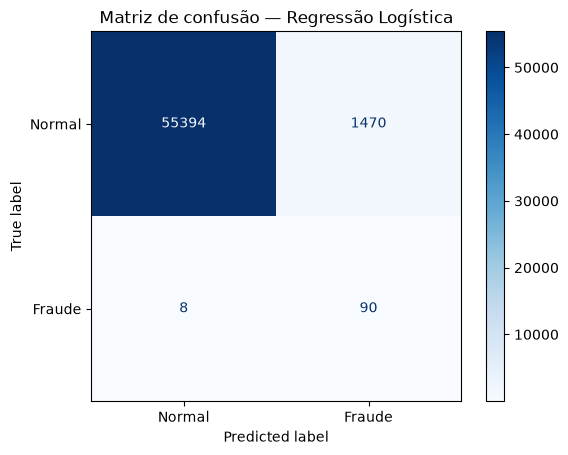


=== Random Forest (limiar 0,5) ===
              precision    recall  f1-score   support

      Normal     0.9997    0.9999    0.9998     56864
      Fraude     0.9186    0.8061    0.8587        98

    accuracy                         0.9995     56962
   macro avg     0.9591    0.9030    0.9292     56962
weighted avg     0.9995    0.9995    0.9995     56962



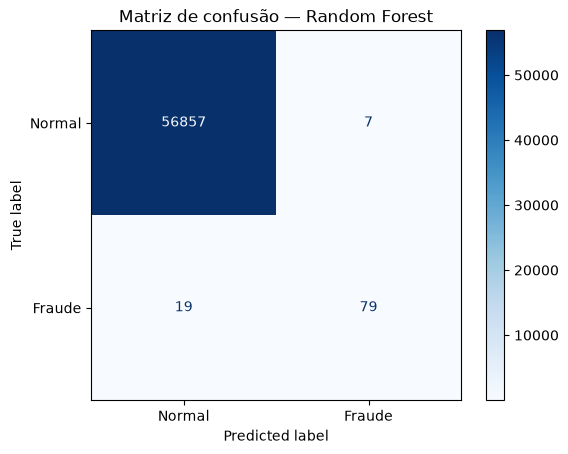


=== XGBoost (limiar 0,5) ===
              precision    recall  f1-score   support

      Normal     0.9997    0.9998    0.9998     56864
      Fraude     0.8817    0.8367    0.8586        98

    accuracy                         0.9995     56962
   macro avg     0.9407    0.9183    0.9292     56962
weighted avg     0.9995    0.9995    0.9995     56962



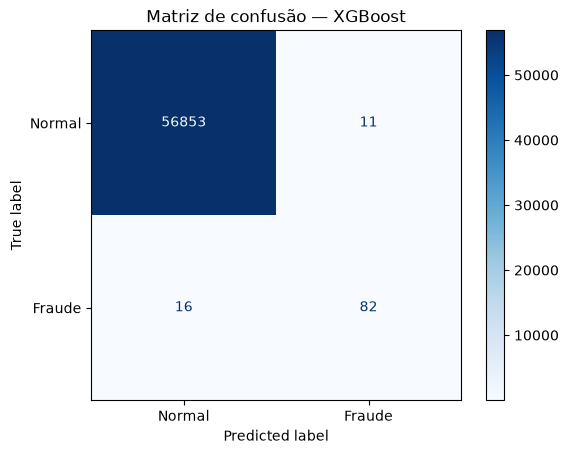

In [16]:
for nome, y_proba in resultados.items():
    y_pred = (y_proba >= 0.5).astype(int)
    print(f"\n=== {nome} (limiar 0,5) ===")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Fraude"], digits=4))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fraude"]).plot(cmap="Blues")
    plt.title(f"Matriz de confusão — {nome}")
    plt.show()

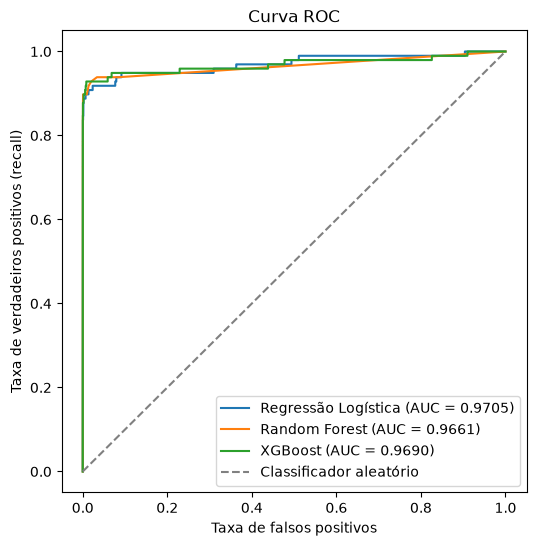

In [17]:
plt.figure(figsize=(6, 6))
for nome, y_proba in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nome} (AUC = {roc_auc_score(y_test, y_proba):.4f})")

plt.plot([0, 1], [0, 1], "--", color="gray", label="Classificador aleatório")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos (recall)")
plt.title("Curva ROC")
plt.legend()
plt.show()

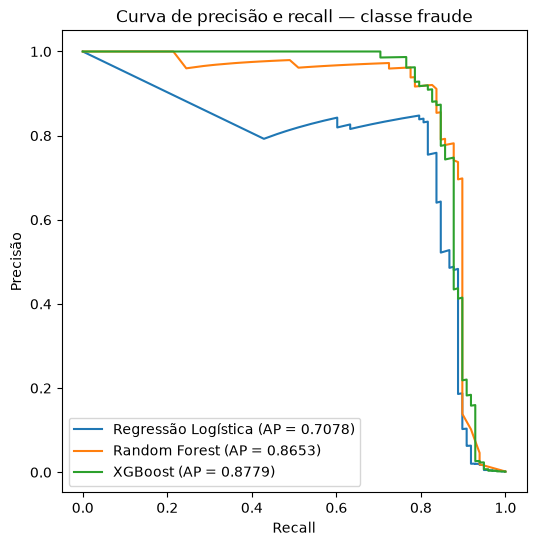

In [18]:
plt.figure(figsize=(6, 6))
for nome, y_proba in resultados.items():
    precisao, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precisao, label=f"{nome} (AP = {average_precision_score(y_test, y_proba):.4f})")

plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curva de precisão e recall — classe fraude")
plt.legend()
plt.show()

**Análise.** Pela curva ROC, os três modelos parecem praticamente equivalentes, com AUC entre 0,966 e 0,971, e a regressão logística aparece até ligeiramente à frente. Já a curva de precisão e recall revela uma diferença que a ROC esconde: a regressão logística é claramente pior (AP = 0,708, contra 0,865 do Random Forest e 0,878 do XGBoost). Isso ocorre porque a ROC usa a taxa de falsos positivos, que fica muito pequena quando há centenas de milhares de transações normais, mascarando os alarmes falsos. A curva de precisão e recall, por considerar diretamente a precisão, é a mais informativa em bases desbalanceadas.

No limiar de 0,5, a regressão logística obtém o maior recall (0,918), mas com precisão de apenas 0,058, o que corresponde a cerca de 1.470 alarmes falsos para 90 fraudes detectadas. Sua acurácia (0,974) chega a ser inferior à do classificador trivial (0,998), ilustrando de forma concreta por que a acurácia não serve como critério neste problema.

### 4.2 Ajuste do limiar de decisão

O limiar de 0,5 pressupõe que os dois tipos de erro têm o mesmo custo, o que não vale aqui: deixar passar uma fraude costuma ser mais grave do que investigar uma transação legítima. Por isso, ajusto o limiar de cada modelo.

**Procedimento.** Para evitar escolher o limiar no conjunto de teste, treino uma cópia de cada modelo apenas no subconjunto `fit` e obtenho suas probabilidades no conjunto de validação. Nesses dados, defino dois limiares candidatos:

- **Regra A (máximo F1):** o limiar que maximiza o F1 da classe fraude;
- **Regra B (prioridade ao recall):** o maior limiar em que o recall da fraude ainda é de pelo menos 0,90, ou seja, o que mais preserva a precisão dentro da meta de recall.

Os limiares escolhidos são então aplicados, sem qualquer reajuste, aos modelos finais no conjunto de teste.

In [19]:
def limiar_max_f1(y_true, y_proba):
    p, r, t = precision_recall_curve(y_true, y_proba)
    f1 = 2 * p * r / (p + r + 1e-12)
    return t[np.argmax(f1[:-1])]  # o último ponto da curva não possui limiar correspondente

def limiar_recall_minimo(y_true, y_proba, recall_alvo=0.90):
    p, r, t = precision_recall_curve(y_true, y_proba)
    candidatos = np.where(r[:-1] >= recall_alvo)[0]
    return t[candidatos[-1]]  # o recall diminui conforme o limiar aumenta; pego o maior limiar que ainda atinge a meta

# modelos auxiliares: mesma configuração, treinados apenas no subconjunto "fit"
modelos_val = {nome: clone(m) for nome, m in modelos.items()}
for nome, m in modelos_val.items():
    X_ajuste = X_fit_scaled if nome == "Regressão Logística" else X_fit
    m.fit(X_ajuste, y_fit)

lim_f1, lim_rec = {}, {}
for nome, m in modelos_val.items():
    proba_val = m.predict_proba(X_de(nome, "val"))[:, 1]
    lim_f1[nome] = limiar_max_f1(y_val, proba_val)
    lim_rec[nome] = limiar_recall_minimo(y_val, proba_val, 0.90)
    print(f"{nome}: limiar (máx. F1) = {lim_f1[nome]:.8f} | limiar (recall >= 0,90) = {lim_rec[nome]:.8f}")

Regressão Logística: limiar (máx. F1) = 0.99999995 | limiar (recall >= 0,90) = 0.29596686
Random Forest: limiar (máx. F1) = 0.40666667 | limiar (recall >= 0,90) = 0.00333333
XGBoost: limiar (máx. F1) = 0.98565972 | limiar (recall >= 0,90) = 0.00003952


**Observação.** Na regressão logística com `class_weight="balanced"`, as probabilidades ficam muito próximas de 1, e por isso o limiar ótimo também fica muito próximo de 1. Isso é um efeito do reponderamento das classes, e não um erro: o peso desloca as probabilidades previstas para cima, e o limiar precisa compensar esse deslocamento. Por isso exibo os limiares com várias casas decimais.

### 4.3 Resultado final no conjunto de teste

A tabela a seguir reúne, para cada modelo, o desempenho no teste com o limiar padrão e com os dois limiares escolhidos na validação. As colunas `VP`, `FP` e `FN` indicam verdadeiros positivos (fraudes detectadas), falsos positivos (alarmes falsos) e falsos negativos (fraudes não detectadas).

In [20]:
regras = [("padrão (0,5)", None), ("máx. F1 (validação)", lim_f1), ("recall >= 0,90 (validação)", lim_rec)]

linhas = []
for nome, y_proba in resultados.items():
    auc = roc_auc_score(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    for regra, limiares in regras:
        lim = 0.5 if limiares is None else limiares[nome]
        y_pred = (y_proba >= lim).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        linhas.append({
            "modelo": nome,
            "regra do limiar": regra,
            "limiar": lim,
            "precisão": tp / (tp + fp) if (tp + fp) else 0.0,
            "recall": tp / (tp + fn),
            "F1": f1_score(y_test, y_pred),
            "VP": tp, "FP": fp, "FN": fn,
            "AUC-ROC": auc,
            "AP": ap,
        })

tabela = pd.DataFrame(linhas).round(
    {"limiar": 8, "precisão": 4, "recall": 4, "F1": 4, "AUC-ROC": 4, "AP": 4}
)
tabela

,modelo,regra do limiar,limiar,precisão,recall,F1,VP,FP,FN,AUC-ROC,AP
0,Regressão Logística,"padrão (0,5)",0.500000,0.0577,0.9184,0.1086,90,1470,8,0.9705,0.7078
1,Regressão Logística,máx. F1 (validação),1.000000,0.8316,0.8061,0.8187,79,16,19,0.9705,0.7078
2,Regressão Logística,"recall >= 0,90 (validação)",0.295967,0.0252,0.9184,0.0491,90,3477,8,0.9705,0.7078
3,Random Forest,"padrão (0,5)",0.500000,0.9186,0.8061,0.8587,79,7,19,0.9661,0.8653
4,Random Forest,máx. F1 (validação),0.406667,0.8632,0.8367,0.8497,82,13,16,0.9661,0.8653
5,Random Forest,"recall >= 0,90 (validação)",0.003333,0.0189,0.9388,0.0370,92,4780,6,0.9661,0.8653
6,XGBoost,"padrão (0,5)",0.500000,0.8817,0.8367,0.8586,82,11,16,0.9690,0.8779
7,XGBoost,máx. F1 (validação),0.985660,0.9740,0.7653,0.8571,75,2,23,0.9690,0.8779
8,XGBoost,"recall >= 0,90 (validação)",0.000040,0.0116,0.9490,0.0230,93,7892,5,0.9690,0.8779


In [21]:
# Relatório detalhado do modelo final, com o limiar escolhido pela regra A
for nome, y_proba in resultados.items():
    y_pred = (y_proba >= lim_f1[nome]).astype(int)
    print(f"\n=== {nome} (limiar = {lim_f1[nome]:.8f}, regra A) ===")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Fraude"], digits=4))


=== Regressão Logística (limiar = 0.99999995, regra A) ===
              precision    recall  f1-score   support

      Normal     0.9997    0.9997    0.9997     56864
      Fraude     0.8316    0.8061    0.8187        98

    accuracy                         0.9994     56962
   macro avg     0.9156    0.9029    0.9092     56962
weighted avg     0.9994    0.9994    0.9994     56962


=== Random Forest (limiar = 0.40666667, regra A) ===
              precision    recall  f1-score   support

      Normal     0.9997    0.9998    0.9997     56864
      Fraude     0.8632    0.8367    0.8497        98

    accuracy                         0.9995     56962
   macro avg     0.9314    0.9183    0.9247     56962
weighted avg     0.9995    0.9995    0.9995     56962


=== XGBoost (limiar = 0.98565972, regra A) ===
              precision    recall  f1-score   support

      Normal     0.9996    1.0000    0.9998     56864
      Fraude     0.9740    0.7653    0.8571        98

    accuracy        

**Análise.** O conjunto de teste contém apenas 98 fraudes; portanto, diferenças de uma ou duas fraudes detectadas alteram visivelmente as métricas (cada fraude equivale a cerca de 1,0 ponto percentual de recall). Por isso, diferenças pequenas entre o Random Forest e o XGBoost não devem ser interpretadas como superioridade de um sobre o outro. Considero que os dois modelos de árvores tiveram desempenho equivalente e superior à regressão logística, com o XGBoost levemente à frente na precisão média (AP).

A comparação entre as regras A e B evidencia o compromisso entre precisão e recall: exigir recall maior implica aceitar mais alarmes falsos. A escolha entre as regras depende do custo relativo dos dois erros, que é uma decisão de negócio e não estatística.

## 5. Explicabilidade

Utilizo duas abordagens complementares: (i) a importância de variáveis dos modelos de árvores, que fornece uma visão global; e (ii) os valores SHAP (Lundberg e Lee, 2017), que decompõem cada previsão individual na contribuição de cada variável.

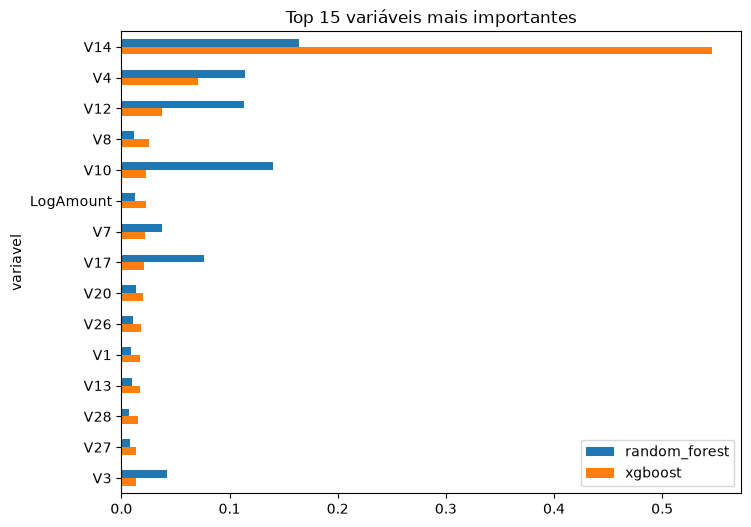

In [22]:
importancias = pd.DataFrame({
    "variavel": features,
    "random_forest": modelos["Random Forest"].feature_importances_,
    "xgboost": modelos["XGBoost"].feature_importances_,
}).sort_values("xgboost", ascending=False)

importancias.head(15).plot(x="variavel", y=["random_forest", "xgboost"], kind="barh", figsize=(8, 6))
plt.title("Top 15 variáveis mais importantes")
plt.gca().invert_yaxis()
plt.show()

**Análise.** As duas árvores concordam que **V14** é a variável mais relevante, embora o XGBoost concentre nela uma parcela muito maior da importância (cerca de 0,55, contra aproximadamente 0,16 no Random Forest). Fora essa concordância, os rankings divergem: o Random Forest distribui a importância entre V10, V4, V12 e V17, enquanto o XGBoost atribui pesos bem menores a essas variáveis. Essa diferença é esperada, pois os algoritmos constroem as árvores de formas distintas (o boosting tende a concentrar-se em poucas variáveis muito discriminativas).

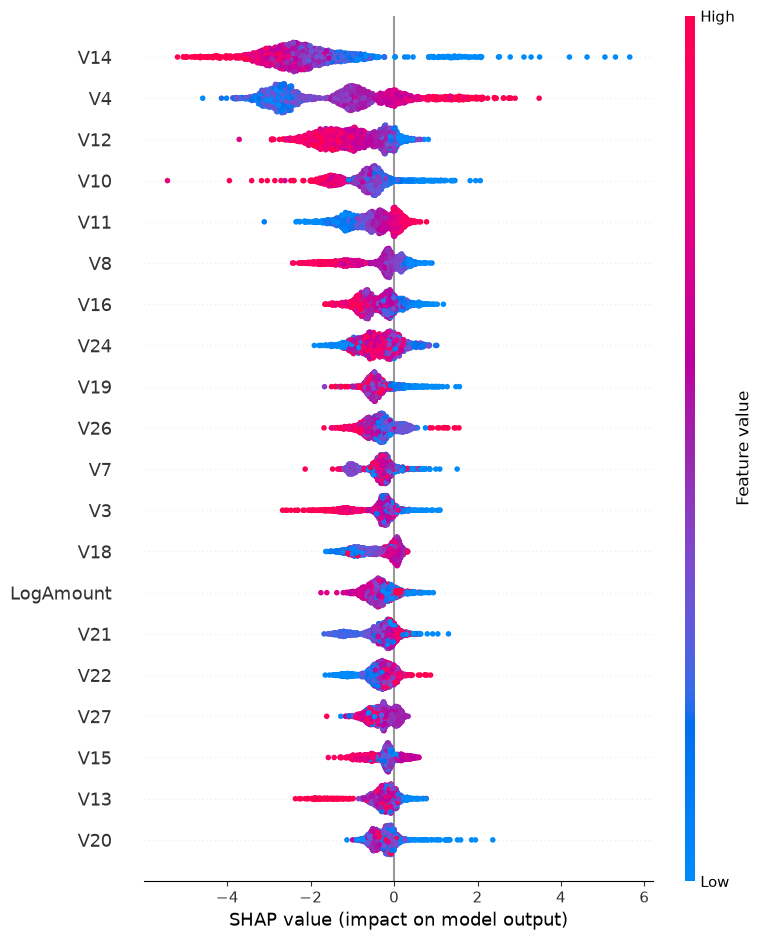

In [23]:
# SHAP para o XGBoost (TreeExplainer é exato e eficiente para modelos de árvores)
explainer = shap.TreeExplainer(modelos["XGBoost"])

# amostra aleatória do teste, para limitar o custo computacional
amostra = X_test.sample(n=min(2000, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(amostra)

shap.summary_plot(shap_values, amostra)

**Análise.** No gráfico de resumo, cada ponto é uma transação; a posição horizontal indica o impacto da variável na previsão (valores positivos aumentam a probabilidade de fraude) e a cor indica o valor da variável. As variáveis de maior impacto são **V14, V4, V12, V10 e V11**. Valores baixos (pontos azuis) de V14, V12 e V10 aparecem à direita do eixo, isto é, aumentam a probabilidade de fraude, enquanto valores altos (pontos vermelhos) de V4 e V11 também deslocam a previsão para a fraude. Como essas variáveis resultam de PCA, não é possível atribuir-lhes um significado de negócio; posso apenas descrever a direção do efeito. A variável criada por mim, `LogAmount`, aparece na região intermediária do ranking, indicando que o valor da transação contribui menos do que os componentes principais.

Classe real da transação: fraude
Probabilidade prevista de fraude: 1.0


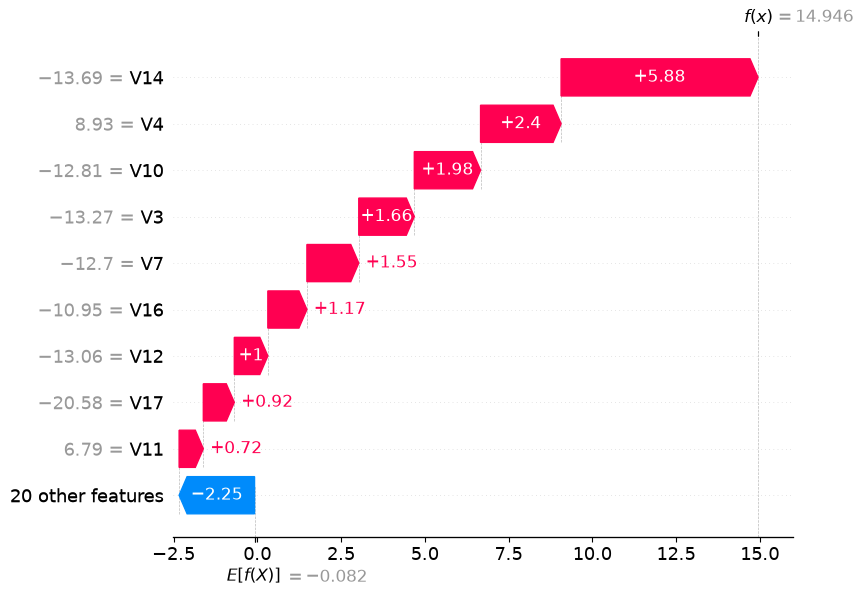

In [24]:
# Explicação individual: a transação com maior probabilidade de fraude segundo o XGBoost
idx = int(np.argmax(resultados["XGBoost"]))
caso = X_test.iloc[[idx]]
print("Classe real da transação:", "fraude" if y_test.iloc[idx] == 1 else "normal")
print("Probabilidade prevista de fraude:", round(float(resultados["XGBoost"][idx]), 6))

sv_caso = explainer.shap_values(caso)
explicacao = shap.Explanation(
    values=sv_caso[0],
    base_values=float(np.ravel(explainer.expected_value)[0]),
    data=caso.iloc[0].round(2).values,
    feature_names=list(caso.columns),
)
shap.plots.waterfall(explicacao, max_display=10)

**Análise.** O gráfico em cascata (waterfall) mostra, para essa transação específica, como cada variável deslocou a previsão a partir do valor base do modelo até o resultado final. Diferentemente do gráfico de resumo, aqui a explicação é local: identifica quais variáveis, com quais valores, levaram esta transação a ser marcada como fraude. Esse tipo de explicação individual é o que permitiria a um analista justificar o bloqueio de uma transação específica.

## 6. Limitações e trabalhos futuros

- **Tamanho amostral da classe positiva.** O conjunto de teste tem apenas 98 fraudes, então as métricas têm incerteza considerável e diferenças pequenas entre modelos não são conclusivas. Uma validação cruzada estratificada, com intervalos de confiança, daria uma comparação mais robusta.
- **Uma única partição.** Todos os resultados vêm de uma única divisão treino/validação/teste. O limiar escolhido depende de uma validação com poucas fraudes e, por isso, é uma estimativa ruidosa.
- **Modelo auxiliar para o limiar.** O limiar é obtido com modelos treinados em 60% dos dados e aplicado aos modelos treinados em 80%; as probabilidades desses modelos podem ter calibração ligeiramente diferente.
- **Amostra do SHAP.** A amostra aleatória de 2.000 transações do teste contém poucas fraudes; uma análise focada nas fraudes reais, ou uma amostra enriquecida, seria mais informativa sobre o que caracteriza uma fraude.
- **Interpretabilidade limitada pelo PCA.** Como as variáveis V1 a V28 são anônimas, não é possível traduzir os resultados do SHAP em regras de negócio.

**Trabalhos futuros:** comparar undersampling e oversampling com o peso de classes; ampliar a busca de hiperparâmetros com `GridSearchCV`, otimizando pela precisão média; criar variáveis de comportamento ao longo do tempo; e testar outros classificadores.

## 7. Conclusão

O principal aprendizado deste trabalho é que, em um problema com 0,17% de casos positivos, a escolha da métrica determina se a análise faz sentido: a acurácia esconderia um modelo inútil, e mesmo a curva ROC não evidenciou a mesma diferença de desempenho observada na curva de precisão e recall, revelada apenas pela curva de precisão e recall. 

No limiar padrão de 0,5, Random Forest e XGBoost apresentaram F1 e precisão muito superiores à regressão logística, enquanto a regressão logística apresentou recall maior, porém ao custo de muitos falsos positivos. O ajuste do limiar, feito em um conjunto de validação separado, e a análise com SHAP completam o ciclo, transformando uma probabilidade em uma decisão justificável.

Ao comparar os modelos com o limiar ajustado na validação, adotei o XGBoost com limiar 0,985660 (regra de máximo F1). No teste, ele obteve precisão de 97,40%, recall de 76,53% e F1 de 85,71%, detectando 75 das 98 fraudes com apenas 2 alarmes falsos. Essa escolha prioriza a precisão: com o limiar padrão de 0,5, o mesmo modelo detectaria 82 fraudes, ao custo de 11 alarmes falsos. Se, no contexto real, deixar passar uma fraude for mais grave do que investigar uma transação legítima, um limiar menor seria mais adequado. Como o conjunto de teste tem apenas 98 fraudes, a diferença entre o XGBoost e o Random Forest não é conclusiva.